# __BELLABEAT CASE STUDY__

### __INTRODUCTION__
Bellabeat is a tech start-up focused on women health. Bellabeat designs wearables to capture data and deliver health insights primarily to the women demographic. The wearable is accompanied by Bellabeat App. The former tracks various health-related data like sleep, heart rate, and respiration while the latter provides the platform and delivers insights. These insights cover a large variety of women health domains including the (i) menstrual cycle, (ii) sleep, (iii) readiness, (iv) stress resistance, and (v) pregnancy tracking.


### __STAKEHOLDERS__

Urška Sršen

### __DATA__
The dataset used for this analysis is the FitBit Fitness Tracker Data and it was made available through Mobius on Kaggle. This Kaggle data set was created between 03.12.2016-05.12.2016 and contains personal fitness tracker from thirty fitbit users. Thirty eligible Fitbit users consented to the submission of personal tracker data, including minute-level output for physical activity, heart rate, and sleep monitoring. It includes information about daily activity, steps, and heart rate that can be used to explore users’ habits.


### __BUSINESS TASK__
Sršen requested for us to analyse smart device usage data in order to gain insight into how consumers use non-Bellabeat smart devices. She then wants us to select one Bellabeat product to apply these insights in our presentation. These questions will guide our analyses:
- What are some trends in smart device usage
- How could these trends apply to Bellabeat customers?
- How could these trends help influence Bellabeat marketing strategy?

Referenced 
https://www.kaggle.com/code/macarenalacasa/capstone-case-study-bellabeat/notebook
https://www.kaggle.com/code/joyokwu/bellabeat-case-study-with-r

In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import datetime
import seaborn as sns

In [32]:
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 10)

In [41]:
folder = './dataset/'
filenames = [folder + i for i in os.listdir(folder)]
for index, name in enumerate(filenames):
    print(index, name)

0 ./dataset/minuteIntensitiesWide_merged.csv
1 ./dataset/dailyActivity_merged.csv
2 ./dataset/sleepDay_merged.csv
3 ./dataset/heartrate_seconds_merged.csv
4 ./dataset/minuteIntensitiesNarrow_merged.csv
5 ./dataset/minuteMETsNarrow_merged.csv
6 ./dataset/hourlySteps_merged.csv
7 ./dataset/hourlyIntensities_merged.csv
8 ./dataset/dailyCalories_merged.csv
9 ./dataset/hourlyCalories_merged.csv
10 ./dataset/minuteSleep_merged.csv
11 ./dataset/minuteCaloriesNarrow_merged.csv
12 ./dataset/dailySteps_merged.csv
13 ./dataset/minuteCaloriesWide_merged.csv
14 ./dataset/minuteStepsNarrow_merged.csv
15 ./dataset/minuteStepsWide_merged.csv
16 ./dataset/weightLogInfo_merged.csv
17 ./dataset/dailyIntensities_merged.csv


### ✖ Data Exploration of the "minuteIntensitiesWide_merged" dataset

Summary: The dataset is pretty comprehensive for the month of April. Only 4 peoples' intensity recordings were not collected for a significant time in that month. However, this was short of the 2 months that was promised. Additioanlly, without knowing what and how intensities is defined, it is hard to make sense of information in this dataset. 

In [222]:
chosen_file = filenames[0]
print(chosen_file)

./dataset/minuteIntensitiesWide_merged.csv


The dataset counts the minutes that the user was engaged in intense activity. One row represents an hour for a particular user

In [261]:
Each colu

df = pd.read_csv(chosen_file)

# converting the ActivityHour column into the datetime data type
df['ActivityHour'] = pd.to_datetime(df['ActivityHour'], format='%m/%d/%Y %I:%M:%S %p')

# S
df['total_intense'] = df.iloc[:, 2:].sum(axis=1)
df = df.loc[:, ['Id', 'ActivityHour', 'total_intense']].copy()
df = df.groupby(by=['Id', pd.Grouper(key='ActivityHour', freq='D')])[['total_intense']].agg('sum').reset_index()
df

,Id,ActivityHour,total_intense
0,1503960366,2016-04-13,318
1,1503960366,2016-04-14,293
2,1503960366,2016-04-15,364
3,1503960366,2016-04-16,349
4,1503960366,2016-04-17,318
...,...,...,...
914,8877689391,2016-05-09,474
915,8877689391,2016-05-10,300
916,8877689391,2016-05-11,501
917,8877689391,2016-05-12,613


In [273]:
df.duplicated().sum()

0

In [274]:
df.isnull().sum()

Id               0
ActivityHour     0
total_intense    0
dtype: int64

In [266]:
intensity_pivot = df.pivot(index=['Id'], columns=['ActivityHour'], values=['total_intense'])
intensity_pivot

total_intense                                              \
ActivityHour    2016-04-13 2016-04-14 2016-04-15 2016-04-16 2016-04-17   
Id                                                                       
1503960366           318.0      293.0      364.0      349.0      318.0   
1624580081           148.0      236.0       96.0      176.0      216.0   
1644430081           257.0      383.0      187.0      449.0      299.0   
1844505072           248.0      373.0      176.0      147.0      221.0   
1927972279            32.0      106.0       51.0        0.0        0.0   
...                    ...        ...        ...        ...        ...   
8253242879           223.0      152.0      105.0      235.0      290.0   
8378563200           545.0      585.0      416.0      376.0       93.0   
8583815059           215.0      134.0       65.0        0.0        0.0   
8792009665            82.0       84.0      126.0       12.0        0.0   
8877689391           576.0      528.0      601.0      769.0      511.0   

                                                                     \
ActivityHour 2016-04-18 2016-04-19 2016-04-20 2016-04-21 2016-04-22   
Id                                                                    
1503960366        391.0      476.0      313.0      284.0      382.0   
1624580081        267.0      141.0      151.0      186.0      199.0   
1644430081        232.0      385.0      125.0       38.0       86.0   
1844505072        241.0       10.0        1.0      340.0      220.0   
1927972279         17.0        0.0        0.0        0.0       10.0   
...                 ...        ...        ...        ...        ...   
8253242879        210.0      164.0      267.0      359.0      120.0   
8378563200        545.0      552.0      431.0      588.0      522.0   
8583815059        161.0      207.0      221.0      299.0      332.0   
8792009665          0.0        0.0      159.0        9.0      238.0   
8877689391        288.0      486.0      482.0      498.0      423.0   

                                                                     \
ActivityHour 2016-04-23 2016-04-24 2016-04-25 2016-04-26 2016-04-27   
Id                                                                    
1503960366        427.0      365.0      463.0      418.0      499.0   
1624580081        227.0      269.0      202.0      140.0      277.0   
1644430081        190.0       89.0      120.0      338.0      118.0   
1844505072        139.0        0.0        0.0        0.0        1.0   
1927972279        145.0       90.0       12.0      192.0        0.0   
...                 ...        ...        ...        ...        ...   
8253242879        333.0      213.0      247.0      193.0      249.0   
8378563200        213.0      135.0      524.0      467.0      212.0   
8583815059        347.0      300.0      188.0      399.0      370.0   
8792009665        346.0       44.0        0.0       80.0      112.0   
8877689391        618.0      421.0      573.0      330.0      530.0   

                                                                     \
ActivityHour 2016-04-28 2016-04-29 2016-04-30 2016-05-01 2016-05-02   
Id                                                                    
1503960366        389.0      315.0      441.0      415.0      430.0   
1624580081        125.0      150.0      303.0      855.0      199.0   
1644430081        342.0      120.0      571.0      203.0      142.0   
1844505072        302.0      247.0      184.0       89.0        0.0   
1927972279         95.0        0.0        0.0      114.0      158.0   
...                 ...        ...        ...        ...        ...   
8253242879         85.0      202.0        NaN        NaN        NaN   
8378563200        192.0      195.0      121.0      360.0      339.0   
8583815059        259.0      530.0      379.0      151.0        0.0   
8792009665        310.0      426.0      371.0       79.0      101.0   
8877689391        421.0      274.0      603.0      298.0      1

In [271]:
intensity_pivot.sum().sum() / np.multiply(intensity_pivot.shape[0], intensity_pivot.shape[1])

255.00879765395894

/var/folders/2h/c7dkm6rj2w318lkvfrnrk2c00000gn/T/ipykernel_17359/874047213.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  labels = intensity_pivot.applymap(lambda x: f'{x}' if x == 0 else '')


<Axes: xlabel='None-ActivityHour', ylabel='Id'>

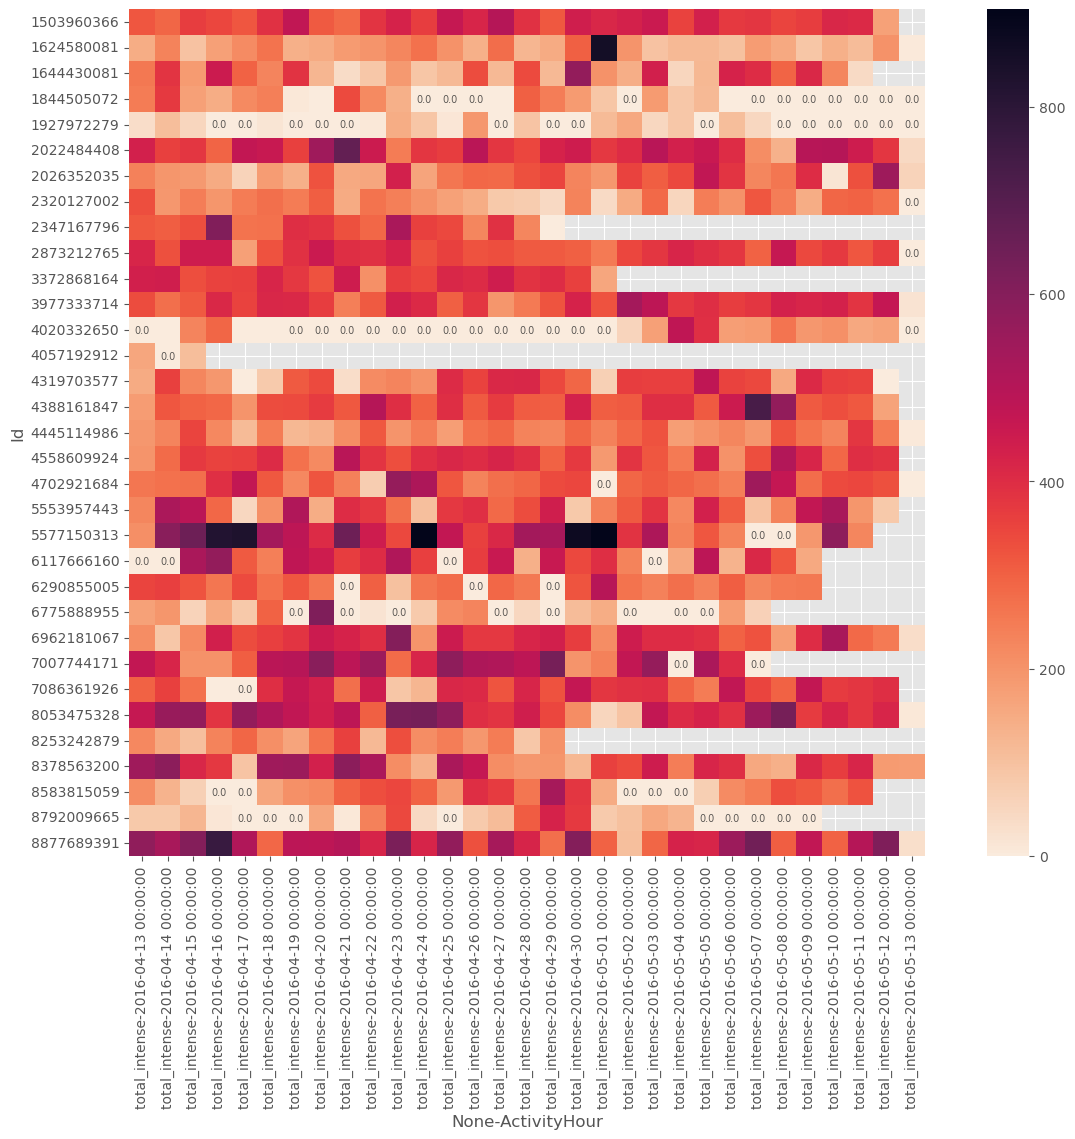

In [284]:
plt.subplots(figsize=(16,11))

labels = intensity_pivot.applymap(lambda x: f'{x}' if x == 0 else '')
sns.heatmap(intensity_pivot, cmap='rocket_r', square=True, 
    annot_kws={'size': 'x-small', 'alpha': 0.75}, 
    annot=labels, 
    fmt = ''
    )

- A day has 1440 minutes. On average, people spend 255 minutes on supposed 'intense' activitys. Without understanding the definition of 'intense', it is sifficult to have a mental picture of what kinds of activities that users are engaged with.
- Only one out of the supposed 2 months are represented in this dataset. Unlike the 'heartrate_second_merged_ dataset, the data campred here is more comprehensive, save for 4 users who had a substantial portion of 'intensities' untracked.
- The 'intensity' data collected for user 5577150313 needs to be further looked into, There are 5 days in his data which exceed 800 minutes, i.e. he was engaged in 'intense activities'. Depending on the definition of 'intense' activities, you could interpret it as engaged in athletic drills (which makes the > 800 number alomost impossible)
- In this vizualisation, 0 is different from null values. 0 represents the absence of any intense activity for that particular day, whereas null value represent the absence of data for that particular day.

### (2) ★ Data exploration of the "dailyActivity_merged" dataset

In [285]:
chosen_file = filenames[1]
print(chosen_file)

./dataset/dailyActivity_merged.csv


In [294]:
df = pd.read_csv(chosen_file, parse_dates=['ActivityDate'])
df

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,2016-04-12,13162,8.500000,8.500000,0.0,1.88,0.55,6.06,0.00,25,13,328,728,1985
1,1503960366,2016-04-13,10735,6.970000,6.970000,0.0,1.57,0.69,4.71,0.00,21,19,217,776,1797
2,1503960366,2016-04-14,10460,6.740000,6.740000,0.0,2.44,0.40,3.91,0.00,30,11,181,1218,1776
3,1503960366,2016-04-15,9762,6.280000,6.280000,0.0,2.14,1.26,2.83,0.00,29,34,209,726,1745
4,1503960366,2016-04-16,12669,8.160000,8.160000,0.0,2.71,0.41,5.04,0.00,36,10,221,773,1863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
935,8877689391,2016-05-08,10686,8.110000,8.110000,0.0,1.08,0.20,6.80,0.00,17,4,245,1174,2847
936,8877689391,2016-05-09,20226,18.250000,18.250000,0.0,11.10,0.80,6.24,0.05,73,19,217,1131,3710
937,8877689391,2016-05-10,10733,8.150000,8.150000,0.0,1.35,0.46,6.28,0.00,18,11,224,1187,2832
938,8877689391,2016-05-11,21420,19.559999,19.559999,0.0,13.22,0.41,5.89,0.00,88,12,213,1127,3832


#### (2) Checking for duplicates and nulls

In [289]:
df.duplicated().sum()

0

In [292]:
df.isnull().sum().sum()

0

In [293]:
df['Id'].nunique()

33

In [296]:
df['ActivityDate'].nunique()

31

In [298]:
df.shape

(940, 15)

#### (2) Exploratory Data Analysis

##### Q1: How many people use their wearables to track the number of steps walked each day?
- The Step column is the most complete dataset. Everyone in the dataset used their weareables to track their step count. There are 12 participants who logged 0 steps for at least one day, there are 4 who logged 0 steps more than 5 days in that month.
- Taking the summary statistics on the steps everyone took in the last 30 days: the range of steps was between 916 and 16,000 steps, the median is 7.2k steps

In [320]:
df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['TotalSteps'])

TotalSteps                                              \
ActivityDate 2016-04-12 2016-04-13 2016-04-14 2016-04-15 2016-04-16   
Id                                                                    
1503960366      13162.0    10735.0    10460.0     9762.0    12669.0   
1624580081       8163.0     7007.0     9107.0     1510.0     5370.0   
1644430081      10694.0     8001.0    11037.0     5263.0    15300.0   
1844505072       6697.0     4929.0     7937.0     3844.0     3414.0   
1927972279        678.0      356.0     2163.0      980.0        0.0   
...                 ...        ...        ...        ...        ...   
8253242879       9033.0     8053.0     5234.0     2672.0     9256.0   
8378563200       7626.0    12386.0    13318.0    14461.0    11207.0   
8583815059       5014.0     5571.0     3135.0     3430.0     5319.0   
8792009665       2564.0     1320.0     1219.0     2483.0      244.0   
8877689391      23186.0    15337.0    21129.0    13422.0    29326.0   

                                                                     \
ActivityDate 2016-04-17 2016-04-18 2016-04-19 2016-04-20 2016-04-21   
Id                                                                    
1503960366       9705.0    13019.0    15506.0    10544.0     9819.0   
1624580081       6175.0    10536.0     2916.0     4974.0     6349.0   
1644430081       8757.0     7132.0    11256.0     2436.0     1223.0   
1844505072       4525.0     4597.0      197.0        8.0     8054.0   
1927972279          0.0      244.0        0.0        0.0        0.0   
...                 ...        ...        ...        ...        ...   
8253242879      10204.0     5151.0     4212.0     6466.0    11268.0   
8378563200       2132.0    13630.0    13070.0     9388.0    15148.0   
8583815059       3008.0     3864.0     5697.0     5273.0     8538.0   
8792009665          0.0        0.0        0.0     3147.0      144.0   
8877689391      15118.0    11423.0    18785.0    19948.0    19377.0   

                                                                     \
ActivityDate 2016-04-22 2016-04-23 2016-04-24 2016-04-25 2016-04-26   
Id                                                                    
1503960366      12764.0    14371.0    10039.0    15355.0    13755.0   
1624580081       4026.0     8538.0     6076.0     6497.0     2826.0   
1644430081       3673.0     6637.0     3321.0     3580.0     9919.0   
1844505072       5372.0     3570.0        0.0        0.0        0.0   
1927972279        149.0     2945.0     2090.0      152.0     3761.0   
...                 ...        ...        ...        ...        ...   
8253242879       2824.0     9282.0     8905.0     6829.0     4562.0   
8378563200      12200.0     5709.0     3703.0    12405.0    16208.0   
8583815059       8687.0     9423.0     8286.0     4503.0    10499.0   
8792009665       4068.0     5245.0      400.0        0.0     1321.0   
8877689391      18258.0    11200.0    16674.0    12986.0    11101.0   

                                                                     \
ActivityDate 2016-04-27 2016-04-28 2016-04-29 2016-04-30 2016-05-01   
Id                                                                    
1503960366      18134.0    13154.0    11181.0    14673.0    10602.0   
1624580081       8367.0     2759.0     2390.0     6474.0    36019.0   
1644430081       3032.0     9405.0     3176.0    18213.0     6132.0   
1844505072          4.0     6907.0     4920.0     4014.0     2573.0   
1927972279          0.0     1675.0        0.0        0.0     2704.0   
...                 ...        ...        ...        ...        ...   
8253242879      10232.0     2718.0     6260.0        0.0        NaN   
8378563200       7359.0     5417.0     6175.0     2946.0    11419.0   
8583815059      12474.0     6174.0    15168.0    10085.0     4512.0   
8792009665       1758.0     6157.0     8360.0     7174.0     1619.0   
8877689391      23629.0    14890.0     9733.0    27745.0    10930.0   

                                 

In [315]:
no_step_info = df.pivot_table(index=['Id'], columns=['ActivityDate'], values=['TotalSteps']).isna()
no_step_info

TotalSteps                                              \
ActivityDate 2016-04-12 2016-04-13 2016-04-14 2016-04-15 2016-04-16   
Id                                                                    
1503960366        False      False      False      False      False   
1624580081        False      False      False      False      False   
1644430081        False      False      False      False      False   
1844505072        False      False      False      False      False   
1927972279        False      False      False      False      False   
...                 ...        ...        ...        ...        ...   
8253242879        False      False      False      False      False   
8378563200        False      False      False      False      False   
8583815059        False      False      False      False      False   
8792009665        False      False      False      False      False   
8877689391        False      False      False      False      False   

                                                                     \
ActivityDate 2016-04-17 2016-04-18 2016-04-19 2016-04-20 2016-04-21   
Id                                                                    
1503960366        False      False      False      False      False   
1624580081        False      False      False      False      False   
1644430081        False      False      False      False      False   
1844505072        False      False      False      False      False   
1927972279        False      False      False      False      False   
...                 ...        ...        ...        ...        ...   
8253242879        False      False      False      False      False   
8378563200        False      False      False      False      False   
8583815059        False      False      False      False      False   
8792009665        False      False      False      False      False   
8877689391        False      False      False      False      False   

                                                                     \
ActivityDate 2016-04-22 2016-04-23 2016-04-24 2016-04-25 2016-04-26   
Id                                                                    
1503960366        False      False      False      False      False   
1624580081        False      False      False      False      False   
1644430081        False      False      False      False      False   
1844505072        False      False      False      False      False   
1927972279        False      False      False      False      False   
...                 ...        ...        ...        ...        ...   
8253242879        False      False      False      False      False   
8378563200        False      False      False      False      False   
8583815059        False      False      False      False      False   
8792009665        False      False      False      False      False   
8877689391        False      False      False      False      False   

                                                                     \
ActivityDate 2016-04-27 2016-04-28 2016-04-29 2016-04-30 2016-05-01   
Id                                                                    
1503960366        False      False      False      False      False   
1624580081        False      False      False      False      False   
1644430081        False      False      False      False      False   
1844505072        False      False      False      False      False   
1927972279        False      False      False      False      False   
...                 ...        ...        ...        ...        ...   
8253242879        False      False      False      False       True   
8378563200        False      False      False      False      False   
8583815059        False      False      False      False      False   
8792009665        False      False      False      False      False   
8877689391        False      False      False      False      False   

                                 

In [325]:
# (no_step_info.sum(axis=1) > 0).sum() # 12
(no_step_info.sum(axis=1) > 10).sum() # 4
# (no_step_info.sum(axis=1) > 15).sum() # 4


4

<Axes: xlabel='None-ActivityDate', ylabel='Id'>

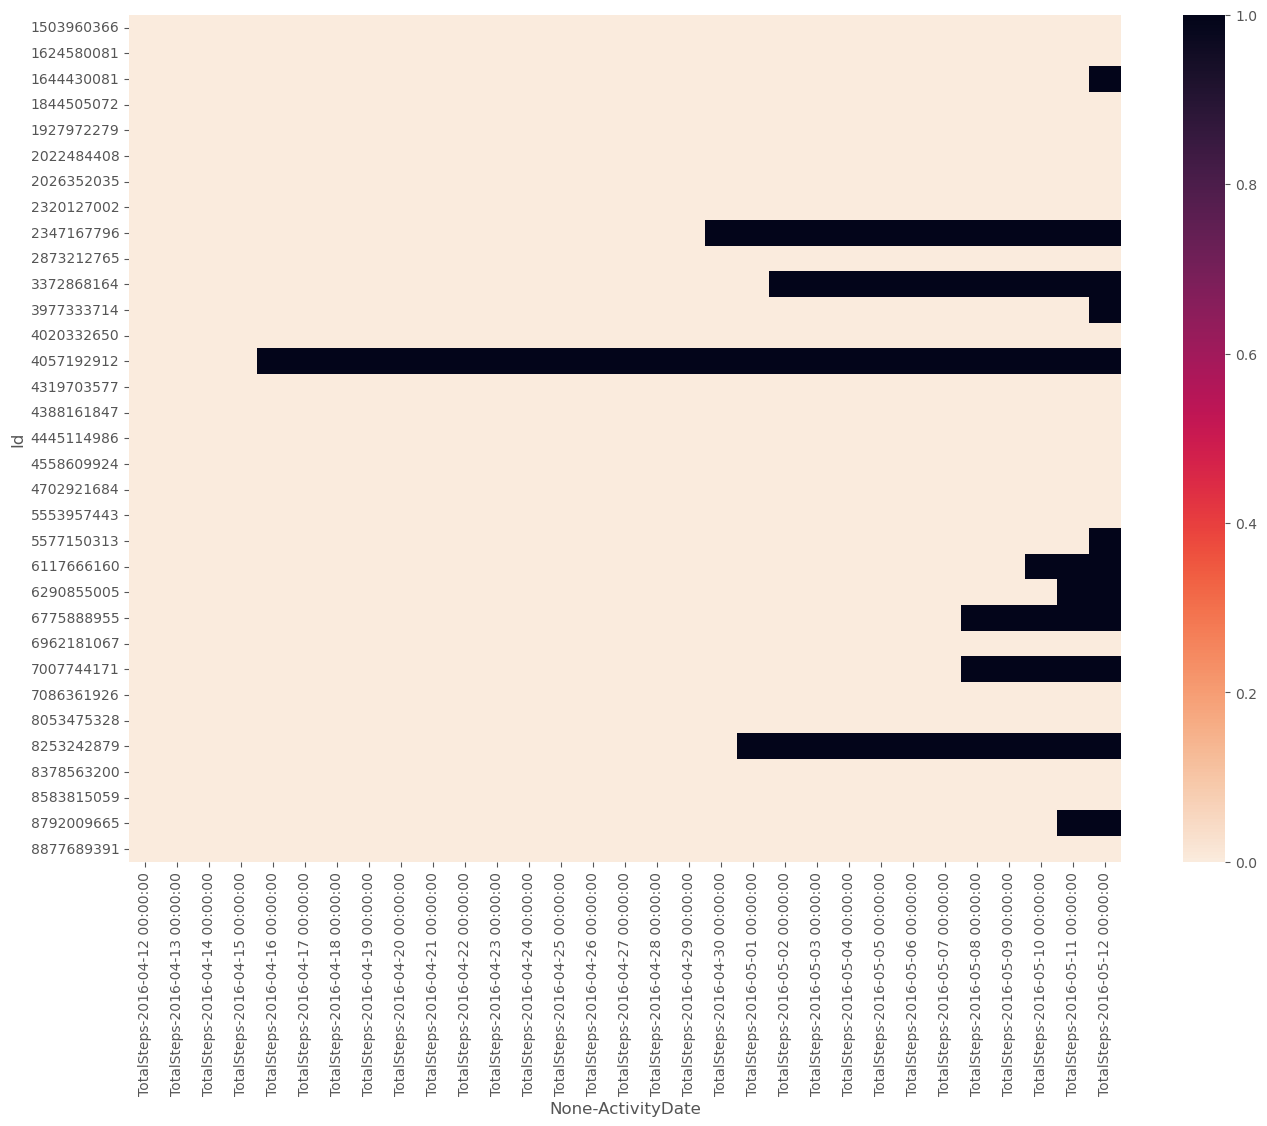

In [309]:
plt.subplots(figsize=(16,11))
sns.heatmap(no_step_info, cmap='rocket_r')

In [337]:
df.groupby('Id')[['TotalSteps']].agg('mean').describe()

,TotalSteps
count,33.000000
mean,7519.272678
std,3576.340125
min,916.129032
25%,5566.870968
50%,7282.966667
75%,9519.666667
max,16040.032258


##### Q2: How many people use their wearables to track the distance walked each day?
- 

#### (2)

### (3) ✖ Data exploration of the "heartrate_second_merged.csv" dataset

Summary: This dataset is quite incomplete, having less than half (14 out of 33) represented in this dataset. Furthermore, recordings were sporadic, and the frequency of collection differed from person to person. While the heart rate/ pulse rate is a useful indicator for the overall cardiac health, the collection of heart/pulse rate data is plagued with issues, such as (i) the lack of regularity in the colection of information, (ii) the lack of reliability in the technology used in the collection of data, and (iii) variance of quality of data which is dependent on how data is collected, with (i) clearly evident in this dataset. It is important, therefore, to understand that data relating to heart/pulse rate has interpretation of the wider lens of existing reliability issues.

One recommendation here is to work with the hardware team to improve the reliability of the devices

In [115]:
chosen_file = filenames[3]
print(chosen_file)
df = pd.read_csv(chosen_file, parse_dates=['Time'])

./dataset/heartrate_seconds_merged.csv


#### (3) Check for duplicates and nulls

In [136]:
df.isnull().sum()

Id       0
Time     0
Value    0
dtype: int64

In [138]:
df.duplicated().sum()

0

- There are ~2.5 million records

In [185]:
f'{df.shape[0]:,}, {df.shape[1]:,}'

'2,483,658, 3'

#### (3) Exploratory Data Analysis

Checking the number of records logged each day for each participant

In [204]:
# Counting the number of records by day for each participant

heartrate_5sec = df.groupby(by=['Id', pd.Grouper(key='Time', freq='D')])[['Value']].agg('count').reset_index()
# heartrate_5sec

In [205]:
# Pivoting the data, and visualising it in a heatmap

heartrate_5sec_pivot = heartrate_5sec.pivot_table(index=['Id'], columns=['Time'], values=['Value'])
heartrate_5sec_pivot

Value                                                         \
Time       2016-04-12 2016-04-13 2016-04-14 2016-04-15 2016-04-16 2016-04-17   
Id                                                                             
2022484408     4836.0     5332.0     5560.0     5302.0     3143.0     4948.0   
2026352035        NaN        NaN        NaN        NaN        NaN      192.0   
2347167796     6753.0     9268.0     9153.0     9557.0     9035.0     8990.0   
4020332650    33963.0        NaN     1448.0    10947.0     8523.0       69.0   
4388161847        NaN     8208.0     7392.0     9205.0     8970.0     8550.0   
4558609924     5973.0     2643.0     5331.0     8102.0     6881.0     6141.0   
5553957443     8370.0     8051.0     9922.0     9135.0     8238.0     1437.0   
5577150313     8685.0     3829.0     9806.0    17001.0    29330.0     8950.0   
6117666160        NaN        NaN        NaN     5443.0     9688.0     5824.0   
6775888955        NaN     4371.0     6099.0     3455.0      589.0      469.0   
6962181067     9196.0     8266.0     8089.0     8355.0     9880.0     8265.0   
7007744171     5506.0     5936.0     5982.0     4249.0     5640.0     5369.0   
8792009665     7587.0     8044.0     7461.0     3605.0        NaN        NaN   
8877689391     8280.0     8577.0     8096.0     9743.0     8431.0     8071.0   

                                                                              \
Time       2016-04-18 2016-04-19 2016-04-20 2016-04-21 2016-04-22 2016-04-23   
Id                                                                             
2022484408     5589.0     4500.0     6040.0     5544.0     5636.0     4178.0   
2026352035        NaN        NaN        NaN        NaN        NaN        NaN   
2347167796     9339.0     7824.0     7156.0     9289.0     9172.0     9543.0   
4020332650        NaN        NaN        NaN        NaN        NaN        NaN   
4388161847     8051.0     9274.0     9216.0     7907.0     7298.0     9326.0   
4558609924     6219.0     4438.0     5135.0     7867.0     6277.0     6342.0   
5553957443     7963.0    10572.0     8239.0     8951.0     9088.0     8275.0   
5577150313     8629.0     8667.0     6535.0    10106.0     8361.0     8519.0   
6117666160     4125.0     9169.0     9182.0     7416.0     9012.0     9450.0   
6775888955     2549.0       26.0     4389.0        NaN      340.0        NaN   
6962181067     7963.0     8612.0     8884.0     9147.0     9065.0     9856.0   
7007744171     6137.0     5737.0     5886.0     5820.0     5825.0     3034.0   
8792009665        NaN        NaN     7765.0      184.0     8429.0     9095.0   
8877689391     6542.0     7877.0     7807.0     7582.0     7885.0     9225.0   

                                                                              \
Time       2016-04-24 2016-04-25 2016-04-26 2016-04-27 2016-04-28 2016-04-29   
Id                                                                             
2022484408     4209.0     3812.0     5586.0     4441.0     5561.0     4832.0   
2026352035        NaN      516.0        NaN        NaN        NaN        NaN   
2347167796     8832.0     9528.0     9023.0     8842.0     9015.0     2364.0   
4020332650        NaN        NaN        NaN        NaN        NaN        NaN   
4388161847     8663.0     7759.0     9229.0     9351.0     7786.0     7489.0   
4558609924     6533.0     6750.0     7409.0     6494.0     7678.0     6943.0   
5553957443     7857.0     9165.0     8923.0     8705.0     9114.0    11959.0   
5577150313     8338.0     8877.0     8764.0     8756.0     9062.0     8712.0   
6117666160     5331.0        NaN     6372.0     9172.0     8044.0     9180.0   
6775888955      347.0     1805.0     1651.0        NaN      309.0       19.0   
6962181067     8643.0     9093.0     8917.0     8595.0     8928.0     9101.0   
7007744171     4138.0     6193.0     7129.0     5761.0     6310.0     6555.0   
8792009665      673.0        NaN     5348.0     8406.0     9374.0     8907.0   
8877689391    

In [215]:
# Here, i will assume that records marked with NA means that there are no heartrate recorded for that day.
check_mean = heartrate_5sec_pivot.fillna(0)

print(check_mean.mean().mean(), check_mean.max().max(), check_mean.min().min())
print(heartrate_5sec_pivot.mean().mean(), heartrate_5sec_pivot.max().max(), heartrate_5sec_pivot.min().min())

5722.714285714286 37357.0 0.0
7478.069993089348 37357.0 19.0


<Axes: xlabel='None-Time', ylabel='Id'>

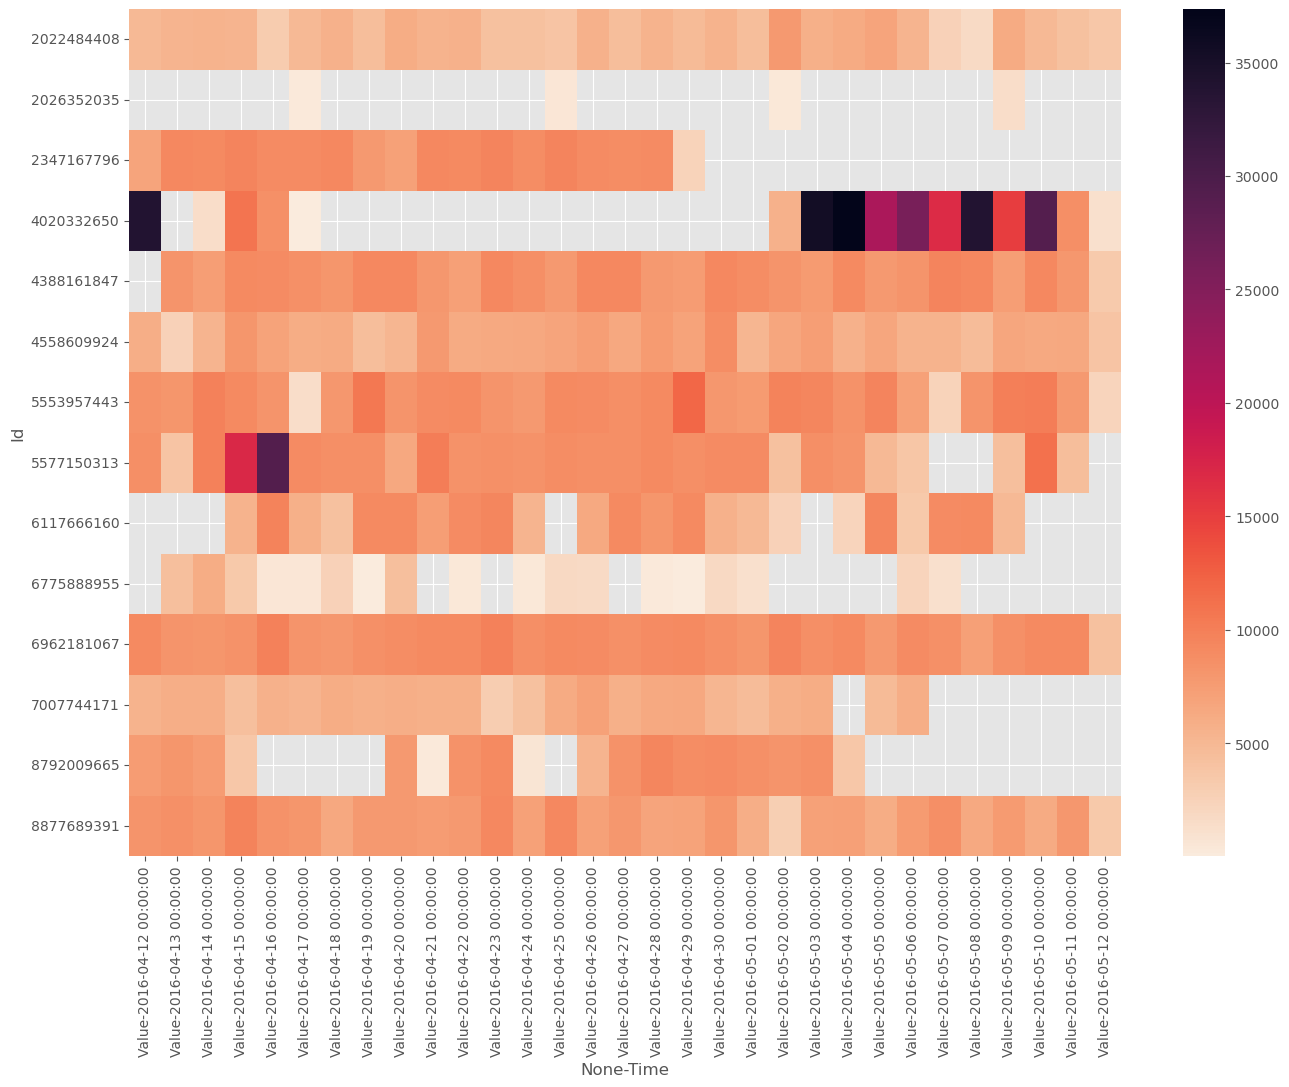

In [196]:
# Pivoting the data, and visualising it in a heatmap

plt.subplots(figsize=(16,11))
sns.heatmap(heartrate_5sec_pivot, cmap='rocket_r', )

Remarks:
- There are 86400 seconds each day, and there are on average ~7.5k (nulls not replaced by zeros) records each day. This works out to be a measurement of heart rate 11-second intervals.
- We know that 2 months of data as well as 30 fitbit users are available in this dataset. However, only 1 month's worth of data and 14 participants were represented in this data. Further, heart rate data collection is irregular for everyone in this dataset.  There are days with higher number of records and days with lower number of records. The highest frequency-interval of heart rate collection is once every 3 seconds.
- In this [journal article][journal], the author acknowledges that use of heart rate has long been used as a clinical indicator of overall cardiac health. Heart rate recordings have historically been collected in discrete laboratory or medical environments that do not represent daily life.
- However, the accuracy of the data arising from wearables has always been an issue.

[journal]: https://www.nature.com/articles/s41746-020-0297-4

---

The following is a time series plot of at least one of the participants

2022484408
2026352035
2347167796


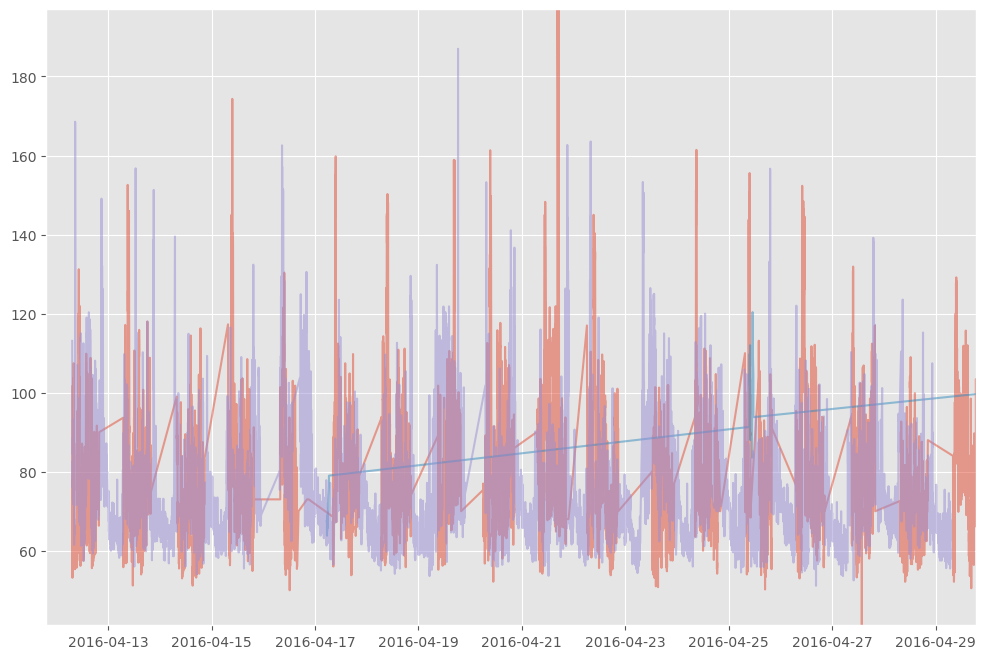

In [221]:
# here we are plotting the heart rate of each user longitutinally at a 1-minute interval

heartrate_1min = df.groupby(by=['Id',pd.Grouper(key='Time', freq='1min')])[['Value']].agg('mean').reset_index()

fig, ax = plt.subplots()
fig.set_size_inches((12,8))

for i in heartrate_1min['Id'].unique()[0:3]:
    print(i)
    data = heartrate_1min.query('Id == @i').drop('Id', axis=1).set_index('Time')

    # The following is for one day
    # x = data[data.index.date == datetime.date(2016,4,12)].index
    # y = data[data.index.date == datetime.date(2016,4,12)].Value

    # Entire dataset
    x = data.index
    y = data.Value
    ax.plot(x,y, alpha = 0.5)

    ax.set_xlim(x.min()-datetime.timedelta(days=0.5), x.max()+datetime.timedelta(days=0.5))
    ax.set_ylim(y.min()-10, y.max()+10)

### Data Exploration of ___ dataset